In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Install required packages
!pip install -q opencv-python-headless pillow pyyaml

# Parking Space Detection — Data Preparation

---
## Prepare environment

In [ ]:
import os
import shutil
import random
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import yaml
import numpy as np
import glob
from pathlib import Path
from collections import defaultdict
from PIL import Image

## Paths & Constants


In [ ]:
# Raw dataset root
BASE_PATH       = "/content/PKLot"
LOCATIONS       = ["UFPR05", "UFPR04", "PUCPR"]
WEATHERS        = ["Cloudy", "Sunny", "Rainy"]

# Intermediate merged folder (flat per location)
MERGED_BASE     = "/content/data/total-content"

# Final split output
SPLIT_BASE      = "/content/data/dataset_split"
TRAIN_LOTS      = ["PUCPR", "UFPR04"]
SPLIT_LOT       = "UFPR05"

# Label settings
CLASS_MAPPING   = {"1": 1, "0": 0}   # 1 = occupied, 0 = empty
IMAGE_EXTS      = (".jpg", ".jpeg", ".png")

random.seed(42)

## Merge Dataset by Location

In [ ]:
for loc in LOCATIONS:
    os.makedirs(os.path.join(MERGED_BASE, loc), exist_ok=True)

for loc in LOCATIONS:
    for weather in WEATHERS:
        weather_path = os.path.join(BASE_PATH, loc, weather)
        for root, _, files in os.walk(weather_path):
            date_folder = os.path.basename(root)
            for file in files:
                src = os.path.join(root, file)
                new_filename = f"{weather}_{date_folder}_{file}"
                dst = os.path.join(MERGED_BASE, loc, new_filename)
                shutil.copy(src, dst)

print("Merge complete.")

Merge complete.


## Exploratory Data Analysis (EDA)

In [ ]:
size_count     = defaultdict(int)
dataset_counts = defaultdict(int)
total_images   = 0

for root, _, files in os.walk(MERGED_BASE):
    depth = root.replace(MERGED_BASE, "").count(os.sep)
    if depth > 2:
        continue

    parts = root.split(os.sep)
    location = next((loc for loc in LOCATIONS if loc in parts), None)

    for file in files:
        if file.lower().endswith(IMAGE_EXTS):
            img_path = os.path.join(root, file)
            if location:
                dataset_counts[location] += 1
            try:
                with Image.open(img_path) as img:
                    size_count[img.size] += 1
                    total_images += 1
            except Exception as e:
                print(f"Error reading {img_path}: {e}")

print("── Images per Location ──")
for loc, count in dataset_counts.items():
    print(f"  {loc:<8} → {count:,} images")

print("\n── Image Resolutions ──")
for size, count in sorted(size_count.items(), key=lambda x: -x[1]):
    print(f"Size:{str(size)} → {count:,} files")

print(f"\nTotal images: {total_images:}")

── Images per Location ──
  UFPR05   → 4,152 images
  UFPR04   → 3,791 images
  PUCPR    → 4,474 images

── Image Resolutions ──
Size:(1280, 720) → 12,417 files

Total images: 12417


## Convert XML Annotations → YOLO Format

In [ ]:
deleted_xml  = 0
error_files  = []
IMAGE_WIDTH  = 1280
IMAGE_HEIGHT = 720

for loc in LOCATIONS:
    folder_path = os.path.join(MERGED_BASE, loc)

    for file in os.listdir(folder_path):
        if not file.endswith(".xml"):
            continue

        xml_path = os.path.join(folder_path, file)
        txt_path = os.path.join(folder_path, file.replace(".xml", ".txt"))

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()

            with open(txt_path, "w") as txt_file:
                for space in root.findall("space"):
                    occupied  = space.get("occupied")
                    cls       = CLASS_MAPPING.get(occupied, -1)
                    if cls == -1:
                        continue

                    rect      = space.find("rotatedRect")
                    center    = rect.find("center")
                    size_node = rect.find("size")

                    cx = float(center.get("x")) / IMAGE_WIDTH
                    cy = float(center.get("y")) / IMAGE_HEIGHT
                    w  = float(size_node.get("w")) / IMAGE_WIDTH
                    h  = float(size_node.get("h")) / IMAGE_HEIGHT

                    txt_file.write(f"{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

            os.remove(xml_path)
            deleted_xml += 1

        except Exception as e:
            error_files.append(file)

print(f"XML converted and removed: {deleted_xml}")
if error_files:
    print(f"Errors ({len(error_files)}): {error_files[:5]}")

XML converted and removed: 12416


## Visualize YOLO Format

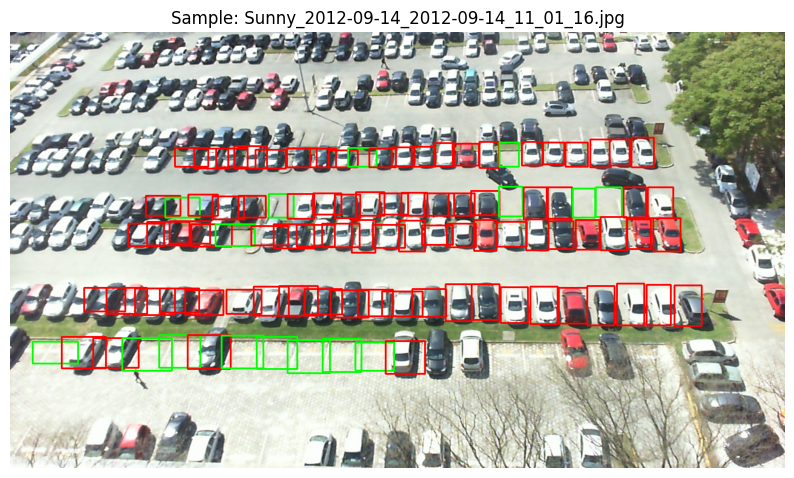

In [ ]:
sample_folder = os.path.join(MERGED_BASE, "PUCPR")
images        = [f for f in os.listdir(sample_folder) if f.endswith(".jpg")]
img_file      = random.choice(images)

img_path   = os.path.join(sample_folder, img_file)
label_path = img_path.replace(".jpg", ".txt")

if not os.path.exists(label_path):
    print("No label found for sampled image.")
else:
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    with open(label_path) as f:
        for line in f:
            cls, x, y, bw, bh = map(float, line.strip().split())
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            color = (0, 255, 0) if int(cls) == 0 else (0, 0, 255)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Sample: {img_file}")
    plt.axis("off")
    plt.show()

## Clean Data — Remove Non-Essential Files

In [ ]:
ALLOWED_EXTS  = (".jpg", ".txt")
deleted_files = 0

for loc in LOCATIONS:
    folder_path = os.path.join(MERGED_BASE, loc)
    for file in os.listdir(folder_path):
        if not file.lower().endswith(ALLOWED_EXTS):
            try:
                os.remove(os.path.join(folder_path, file))
                deleted_files += 1
            except Exception as e:
                print(f"Could not delete {file}: {e}")

print(f"Cleanup complete: {deleted_files} file(s) removed.")

Cleanup complete: 5 file(s) removed.


## Integrity Check — Remove Orphan Images (Missing Labels Data)

In [ ]:
missing_labels = []
total_images   = 0

print("── Dataset Summary ──")

for loc in LOCATIONS:
    folder_path = os.path.join(MERGED_BASE, loc)
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(".jpg")]
    labels = [f for f in os.listdir(folder_path) if f.endswith(".txt")]

    total_images += len(images)
    loc_missing = [
        os.path.join(folder_path, img)
        for img in images
        if not os.path.exists(os.path.join(folder_path, os.path.splitext(img)[0] + ".txt"))
    ]
    missing_labels.extend(loc_missing)

    print(f"  {loc:<8} │ Images: {len(images):5,} │ Labels: {len(labels):5,} │ Missing: {len(loc_missing)}")

print(f"\n  Total images : {total_images:,}")
print(f"  Orphan images: {len(missing_labels)}")

# Remove orphan images
for img_path in missing_labels:
    os.remove(img_path)

if missing_labels:
    print(f"\n {len(missing_labels)} orphan image(s) removed.")
else:
    print("\n No orphan images found.")

── Dataset Summary ──
  UFPR05   │ Images: 4,152 │ Labels: 4,152 │ Missing: 0
  UFPR04   │ Images: 3,791 │ Labels: 3,791 │ Missing: 0
  PUCPR    │ Images: 4,474 │ Labels: 4,473 │ Missing: 1

  Total images : 12,417
  Orphan images: 1

 1 orphan image(s) removed.


## Split Dataset

| Split      | Parking Lot            | Approx. |
|------------|------------------------|---------|
| Train      | PUCPR + UFPR04         | ~66%    |
| Validation | UFPR05 (first half)    | ~17%    |
| Test       | UFPR05 (second half)   | ~17%    |


In [ ]:
# Create output directory structure
for split in ["train", "valid", "test"]:
    os.makedirs(os.path.join(SPLIT_BASE, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(SPLIT_BASE, split, "labels"), exist_ok=True)

# Helper functions
def get_images(folder):
    return sorted(
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTS)
    )

def copy_pair(img_path, split):
    #Copy an image and its label to the target split folder
    lbl_path = os.path.splitext(img_path)[0] + ".txt"
    shutil.copy2(img_path, os.path.join(SPLIT_BASE, split, "images", os.path.basename(img_path)))
    shutil.copy2(lbl_path, os.path.join(SPLIT_BASE, split, "labels", os.path.basename(lbl_path)))
    return 1

# 1. Train: PUCPR + UFPR04
train_count = 0
for lot in TRAIN_LOTS:
    imgs = get_images(os.path.join(SPLIT_BASE.replace("dataset_split", "total-content"), lot))
    print(f"[Train] {lot}: {len(imgs):,} images")
    for img in imgs:
        train_count += copy_pair(img, "train")

# 2. Validation / Test: UFPR05
split_imgs = get_images(os.path.join(SPLIT_BASE.replace("dataset_split", "total-content"), SPLIT_LOT))
random.shuffle(split_imgs)

half        = len(split_imgs) // 2
valid_count = sum(copy_pair(img, "valid") for img in split_imgs[:half])
test_count  = sum(copy_pair(img, "test")  for img in split_imgs[half:])
print(f"[Valid] UFPR05 first half : {valid_count:,} images")
print(f"[Test]  UFPR05 second half: {test_count:,} images")

[Train] PUCPR: 4,473 images
[Train] UFPR04: 3,791 images
[Valid] UFPR05 first half : 2,076 images
[Test]  UFPR05 second half: 2,076 images


In [ ]:
# Summary
print("-"*50)
print("  SPLIT SUMMARY")
total = 0

for split in ["train", "valid", "test"]:
    imgs = os.listdir(os.path.join(SPLIT_BASE, split, "images"))
    lbls = os.listdir(os.path.join(SPLIT_BASE, split, "labels"))
    total += len(imgs)
    pct = len(imgs) / max(total, 1) * 100
    print(f"  {split:<6} │ images: {len(imgs):5,} │ labels: {len(lbls):5,}")
print("-"*50)
print(f"  {'TOTAL':<6} │ images: {total:5,}")
print("-"*50)



--------------------------------------------------
  SPLIT SUMMARY
  train  │ images: 8,264 │ labels: 8,264
  valid  │ images: 2,076 │ labels: 2,076
  test   │ images: 2,076 │ labels: 2,076
--------------------------------------------------
  TOTAL  │ images: 12,416
--------------------------------------------------


## Create data.yaml

YOLO training requires a `data.yaml` that points to the split folders and defines class names.

In [ ]:
DATASET_DIR = Path(SPLIT_BASE)

CLASS_NAMES = ["empty", "occupied"]
NUM_CLASSES = len(CLASS_NAMES)

# Write data.yaml
DATA_YAML = DATASET_DIR / "data.yaml"
yaml_content = f"""
train: train/images
val: valid/images
test: test/images

nc: {NUM_CLASSES}
names: {CLASS_NAMES}
"""

with open(DATA_YAML, "w") as f:
    f.write(yaml_content)

print("data.yaml created:")
print(yaml_content)

data.yaml created:

train: train/images
val: valid/images
test: test/images

nc: 2
names: ['empty', 'occupied']



## Show Class Distribution

In [ ]:
with open(DATA_YAML) as f:
    cfg = yaml.safe_load(f)

def count_labels(split):
    label_dir = os.path.join(DATASET_DIR, split, 'labels')
    counts = {n: 0 for n in cfg['names']}
    total_images = 0
    for lf in glob.glob(label_dir + '/*.txt'):
        total_images += 1
        with open(lf) as f:
            for line in f:
                cls = int(line.split()[0])
                counts[cfg['names'][cls]] += 1
    return counts, total_images

for split in ['train', 'valid', 'test']:
    c, n = count_labels(split)
    print(f"\n{split.upper()} — {n} images")
    for k, v in c.items():
        print(f"  {k}: {v} instances")


TRAIN — 8264 images
  empty: 289619 instances
  occupied: 238351 instances

VALID — 2076 images
  empty: 33437 instances
  occupied: 49434 instances

TEST — 2076 images
  empty: 34922 instances
  occupied: 47992 instances


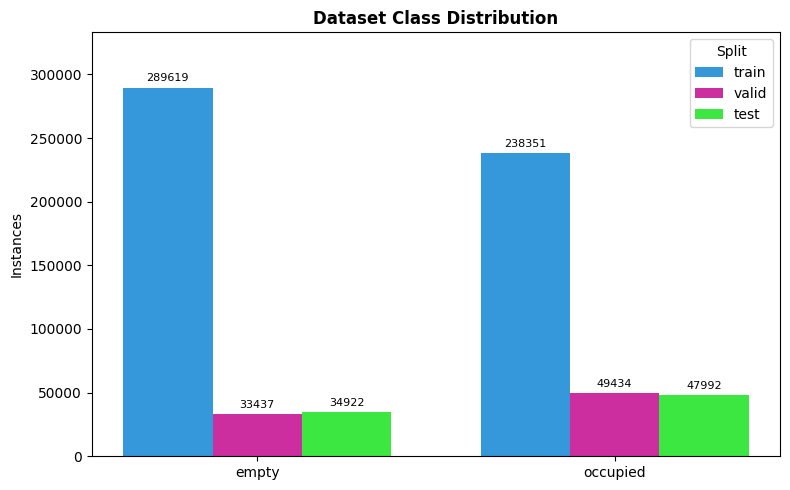

In [ ]:
# chart
splits = ['train', 'valid', 'test']
all_counts = {split: count_labels(split)[0] for split in splits}
class_names = cfg['names']

x = np.arange(len(class_names))
width = 0.25
colors = ['#3498DB', "#CC2E9F", "#3CE742"]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (split, color) in enumerate(zip(splits, colors)):
    values = [all_counts[split][name] for name in class_names]
    bars = ax.bar(x + i * width, values, width, label=split, color=color)
    ax.bar_label(bars, padding=3, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(class_names)
ax.set_ylabel('Instances')
ax.set_title('Dataset Class Distribution', fontweight='bold')
ax.legend(title='Split')
ax.set_ylim(0, max(v for d in all_counts.values() for v in d.values()) * 1.15)

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()